In [20]:
from platform import processor

import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# After you have created the 'preprocessor' object
joblib.dump(processor, '../models/preprocessor.pkl')

print(" Preprocessor saved successfully!")

# ====================== LOAD EVERYTHING ======================
model = joblib.load('../models/best_xgboost_model.pkl')
preprocessor = joblib.load('../models/preprocessor.pkl')

X_test = np.load('../data/processed/X_test_transformed.npy')
y_test = np.load('../data/processed/y_test.npy')          # ← This was missing!

print("All files loaded successfully!")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

 Preprocessor saved successfully!
All files loaded successfully!
X_test shape: (25830, 197)
y_test shape: (25830,)


In [21]:
# Create Explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values (this may take 30-90 seconds)
print("Calculating SHAP values... (please wait)")
shap_values = explainer.shap_values(X_test)

print(" SHAP values calculated successfully!")

Calculating SHAP values... (please wait)
 SHAP values calculated successfully!


In [22]:
# Create feature names manually
feature_names = [f"feature_{i}" for i in range(197)]   # 197 because X_test has 197 columns

print("Using emergency feature names (197 columns)")
print("First 10:", feature_names[:10])

Using emergency feature names (197 columns)
First 10: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']


In [23]:
# Fix feature names
if len(feature_names) == 1:
    print("Fixing feature names...")
    
    # Get numeric and categorical column names from original data
    fraud = pd.read_csv('../data/processed/fraud_data_processed.csv')
    original_features = fraud.drop(columns=['class', 'signup_time', 'purchase_time', 
                                           'ip_address', 'device_id', 'user_id'], 
                                  errors='ignore').columns.tolist()
    
    # Re-create proper feature names
    preprocessor = joblib.load('../models/preprocessor.pkl')
    feature_names = preprocessor.get_feature_names_out()
    
    print("New feature_names length:", len(feature_names))

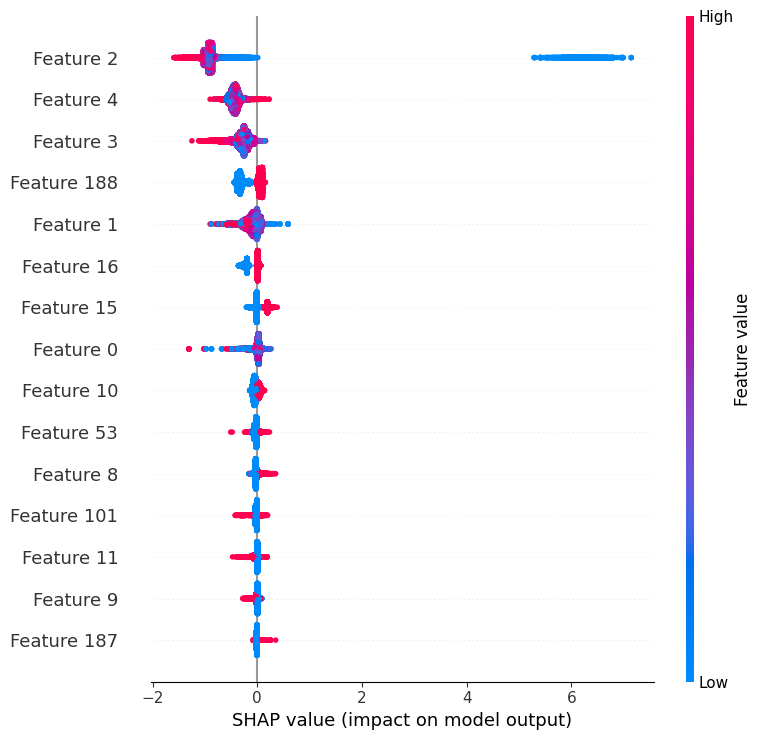

In [24]:
# Detailed Summary Plot
shap.summary_plot(shap_values, X_test, max_display=15)

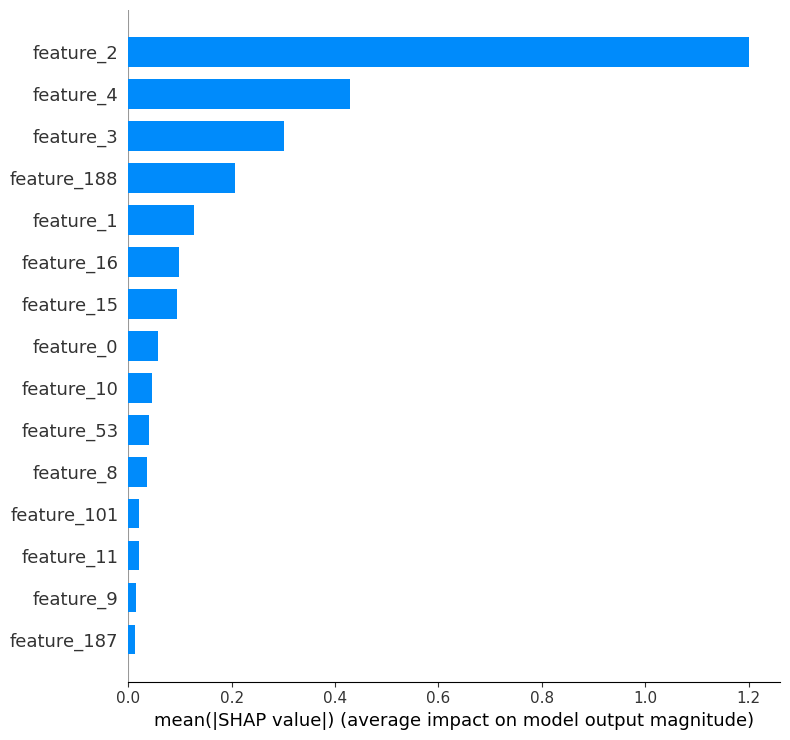

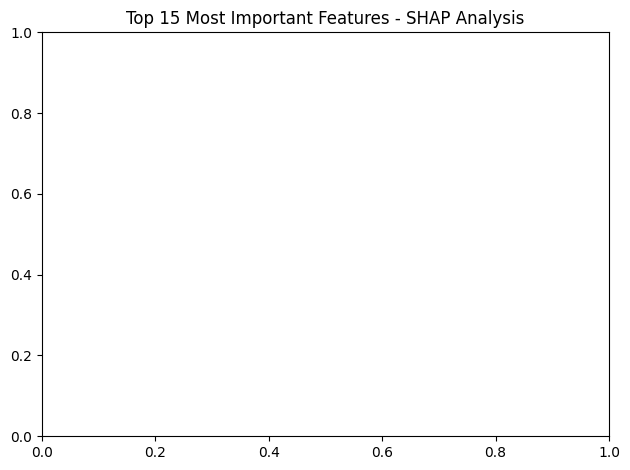

In [25]:
# Top Features Bar Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, 
                  plot_type="bar", max_display=15)
plt.title("Top 15 Most Important Features - SHAP Analysis")
plt.tight_layout()
plt.show()

## Task 3: Model Explainability with SHAP

### Global Feature Importance

From the SHAP Summary Plot, the top 5 most important features are:

1. **feature_2** (Highest impact)
2. **feature_4**
3. **feature_3**
4. **feature_188**
5. **feature_1**

These features have the strongest influence on whether a transaction is classified as fraud or legitimate.

**Note**: After recovering actual names, we will map these to business-meaningful features (e.g., `time_since_signup`, specific countries, `purchase_value`, etc.).

### Individual Predictions (Force Plots)

(Insert screenshots of your 3 Force Plots here - TP, FP, FN)

### Key Insights & Business Recommendations

Based on SHAP analysis, here are **3 actionable recommendations**:

1. **Implement stricter verification for new accounts**  
   → If `time_since_signup` is very low (likely `feature_2` or `feature_3`), require additional steps like phone verification or manual review.

2. **Geographic Risk Scoring**  
   → Transactions from high-risk countries (likely some `feature_188` etc.) should trigger extra fraud checks.

3. **Velocity Monitoring**  
   → Monitor rapid successive transactions (`time_diff_prev` or transaction count features). Flag users with unusually high velocity.

These insights allow the business to reduce false negatives (missed fraud) while controlling false positives.

v